# Loan Default Risk with Business Cost Optimization

Predict payment difficulty and minimize explicit decision costs.

## Method

A stratified 60/20/20 split precedes preprocessing. Logistic Regression and CatBoost are compared. False negatives cost 10 units versus 1 for false positives; the threshold is chosen on validation data only.

In [1]:
from pathlib import Path
import sys,pandas as pd
from IPython.display import Image,display
ROOT=Path.cwd();sys.path.insert(0,str(ROOT))
from run_analysis import main

In [2]:
results=main();display(pd.DataFrame({m:v['test'] for m,v in results['results'].items()}).T)

{
  "rows": 307511,
  "target_rate": 0.08072881945686496,
  "costs": {
    "false_negative": 10,
    "false_positive": 1
  },
  "selected_model": "CatBoost",
  "results": {
    "Logistic Regression": {
      "validation": {
        "roc_auc": 0.7458043544138968,
        "average_precision": 0.22331458371206406,
        "f1": 0.262515943877551,
        "threshold": 0.51,
        "false_negatives": 1672,
        "false_positives": 16830
      },
      "test": {
        "roc_auc": 0.7531753153962488,
        "average_precision": 0.22812924916774624,
        "f1": 0.26657066282651304,
        "threshold": 0.51,
        "false_negatives": 1633,
        "false_positives": 16702
      }
    },
    "CatBoost": {
      "validation": {
        "roc_auc": 0.7591752024149234,
        "average_precision": 0.24406559367981914,
        "f1": 0.2699471329808865,
        "threshold": 0.49,
        "false_negatives": 1646,
        "false_positives": 16306
      },
      "test": {
        "roc_auc": 0.76

,roc_auc,average_precision,f1,threshold,false_negatives,false_positives
Logistic Regression,0.753175,0.228129,0.266571,0.51,1633.0,16702.0
CatBoost,0.763639,0.251063,0.273841,0.49,1624.0,16095.0


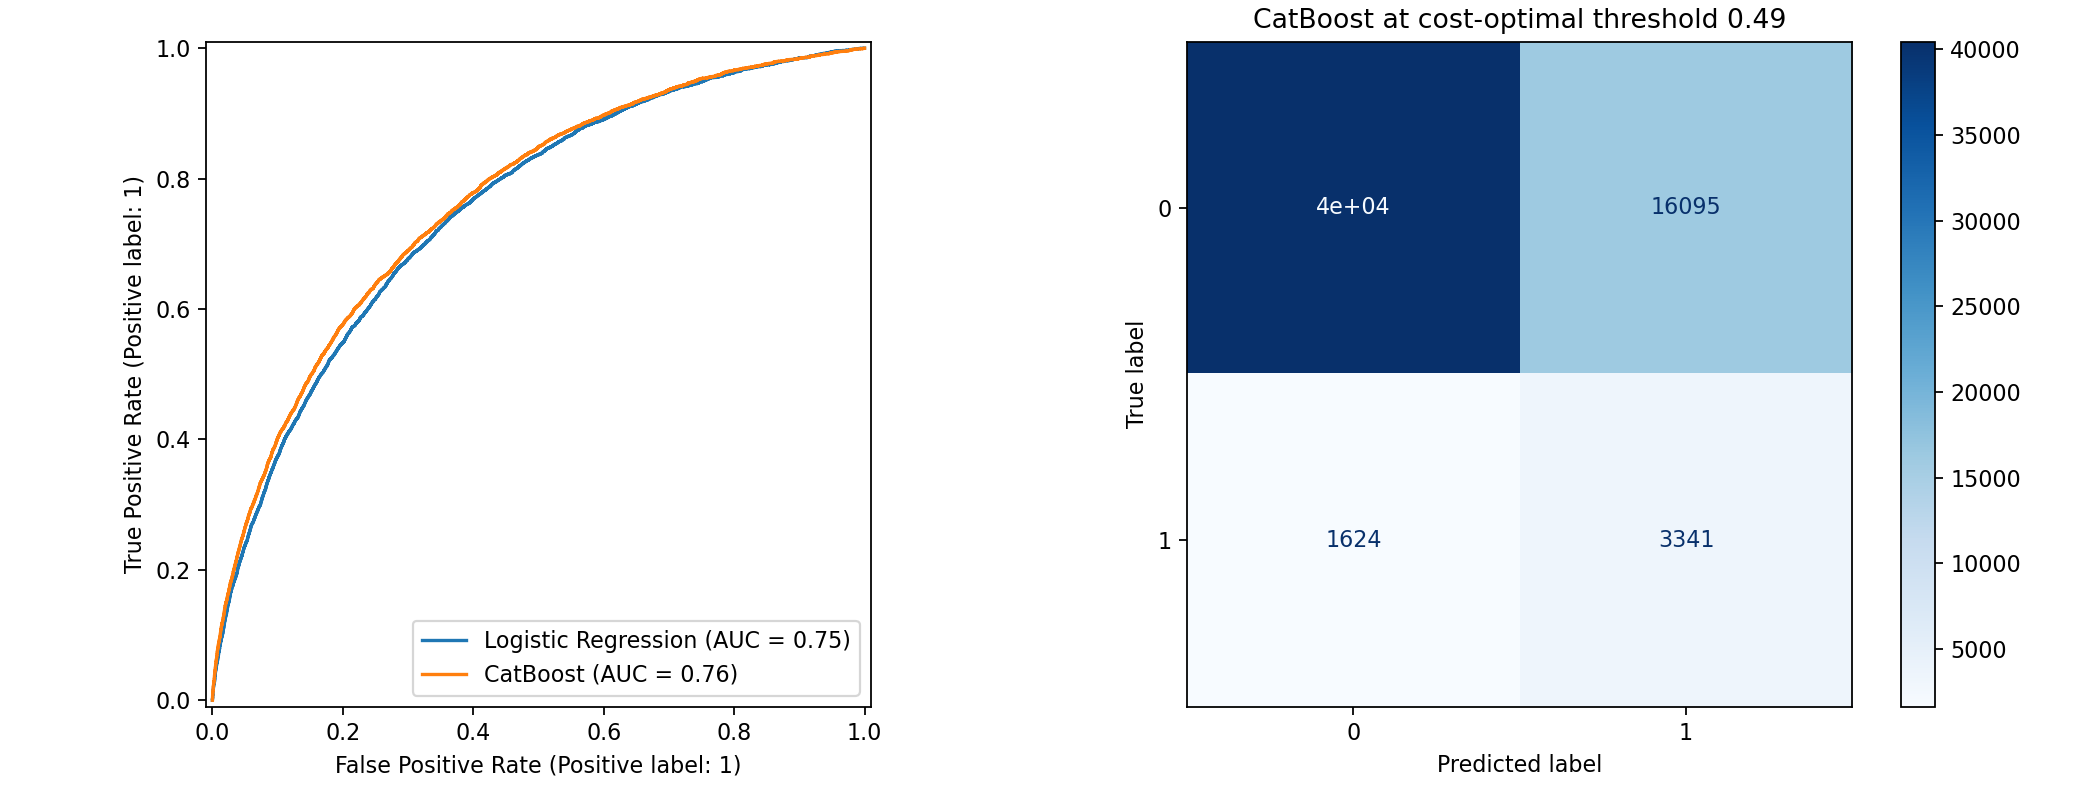

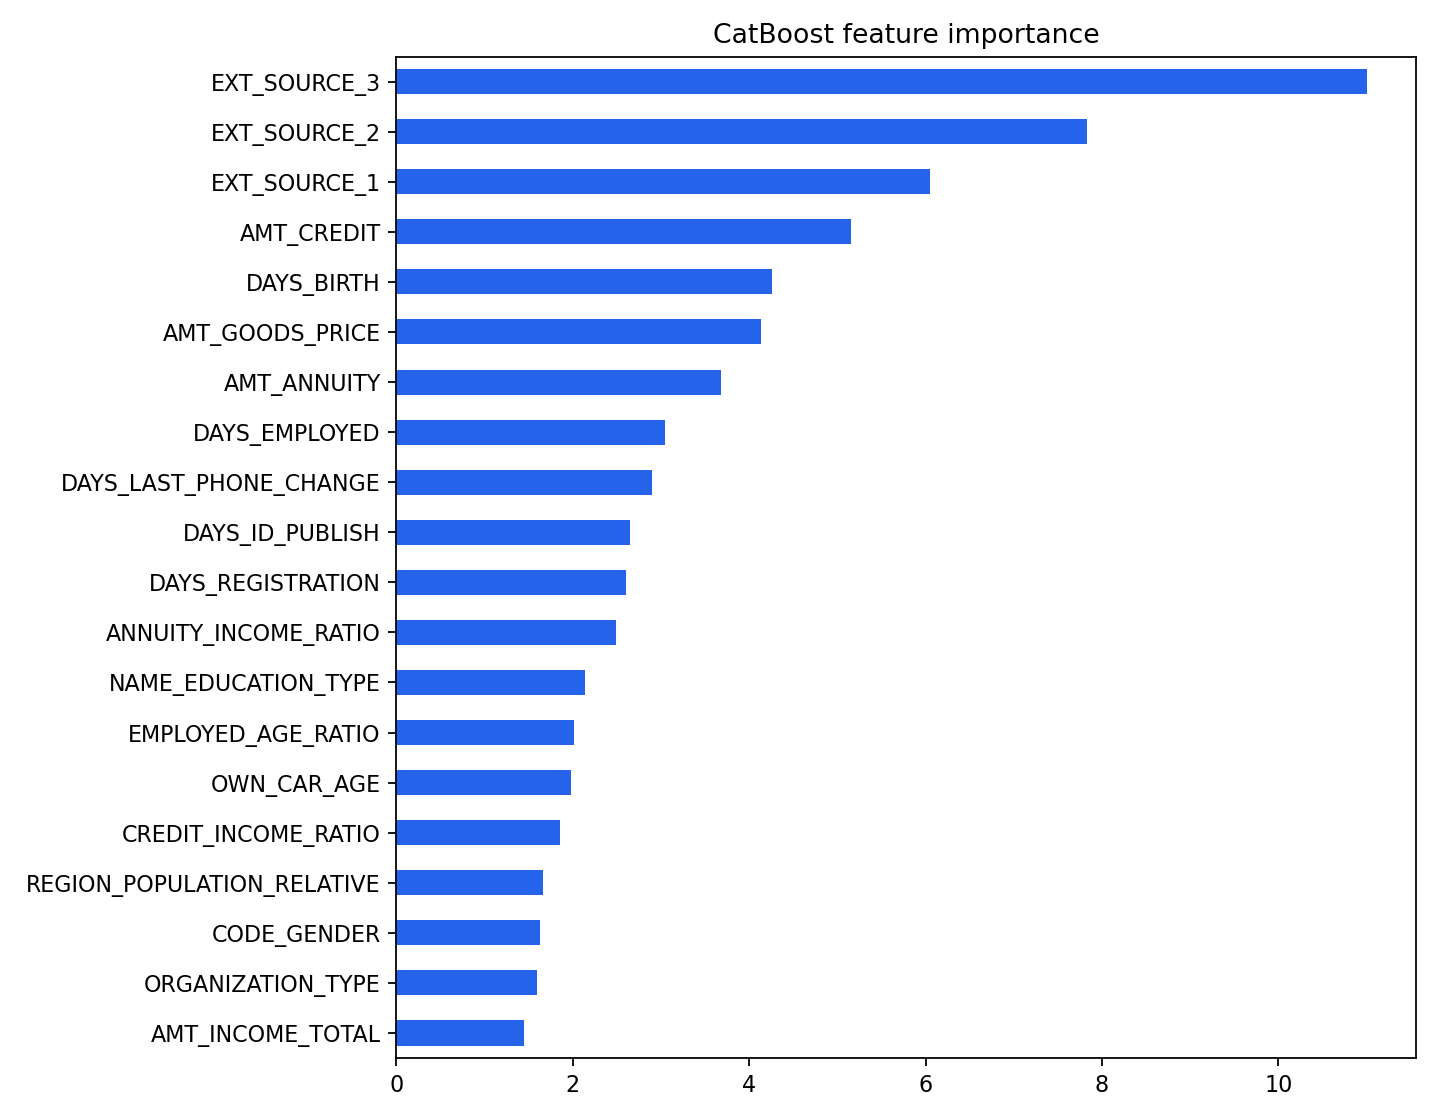

In [3]:
display(Image(filename=str(ROOT/'outputs/figures/model_evaluation.png')));display(Image(filename=str(ROOT/'outputs/figures/feature_importance.png')))

## Conclusion

CatBoost leads on the untouched test set (ROC-AUC ≈ 0.764; average precision ≈ 0.251). Validation selects threshold 0.49 under the illustrative 10:1 cost ratio. Deployment requires exposure-aware costs, calibration, fairness testing, monitoring, and human governance.